# Final EDA — Iowa Liquor Sales (2025 & 2026), Weather, and University Cities

This notebook combines the work spread across the team's separate EDA
notebooks into one pipeline + analysis, so we have a single source of truth:

- **`eda.ipynb`** — loading the raw JSON into a queryable parquet file with
  DuckDB, and the first pass of aggregations/visualizations (top zip codes,
  top stores, monthly/seasonal trends, top categories, county choropleths).
- **`minh.ipynb`** — data cleaning notes: `sales_bottles` needs to be cast to
  numeric, and there's a real population of **negative `sales_dollars`**
  rows (returns/credits) worth flagging before modeling on it. Also the
  log-transform for `sales_dollars`, which is heavily right-skewed.
- **`jake_eda.ipynb`** — flagging store cities that host an Iowa college or
  university, and comparing alcohol sales between university and
  non-university cities.
- **`otis_eda.ipynb`** — pulling accompanying daily weather from the Iowa
  Environmental Mesonet (IEM), matched to each sale's zip code via the
  nearest ASOS station, with a statewide-average fallback for sales that
  can't be matched to a specific zip/county.

`eda.ipynb`, `minh.ipynb`, `jake_eda.ipynb`, and `otis_eda.ipynb` are left
untouched — this is a clean, from-scratch notebook that reruns each piece
against the current data and adds a couple of new sections that tie the
pieces together (in particular, whether weather actually correlates with
sales, which none of the individual notebooks checked yet).

A couple of things surfaced while combining these that are called out
inline as they come up:
- The 2026 data is **year-to-date** (through August as of this notebook),
  while 2025 is a complete year — monthly/seasonal comparisons between the
  two need to account for that.
- The underlying JSON files have grown since `eda.ipynb` was last run
  (1,952,161 rows then vs. more now for 2026) — so exact figures here won't
  match that notebook's saved output precisely, but the shapes of the
  findings hold.
- Recomputing the university-city comparison from the current data gives a
  materially different **average**-gallons ratio than `jake_eda.ipynb`
  reported (both notebooks agree closely on the **total**-gallons ratio).
  That's flagged in that section rather than silently using either number.

In [1]:
import io
import zipfile

import duckdb as db
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

pd.set_option("display.max_columns", None)

## 1. Load the Iowa liquor sales data (2025 + 2026)

Same approach as `eda.ipynb` / `otis_eda.ipynb`: use DuckDB's
`read_json_auto` to convert each year's JSON dump into a parquet file (much
faster to re-read than re-parsing JSON every time), then load into pandas.

We keep `df_2025` and `df_2026` separate (matching what the weather join in
`otis_eda.ipynb` expects), and also build a combined `df_all` with a `year`
column for anything we want to compare across years.

In [2]:
con = db.connect()

con.execute("""
    COPY (
        SELECT *
        FROM read_json_auto(
            'iowa_liquor_sales_2025_1262_rows/**/*.json'
        )
    )
    TO 'liquor_2025.parquet' (FORMAT PARQUET)
""")

con.execute("""
    COPY (
        SELECT *
        FROM read_json_auto(
            'iowa_liquor_sales_2026_1263_rows/**/*.json'
        )
    )
    TO 'liquor_2026.parquet' (FORMAT PARQUET)
""")

df_2025 = pd.read_parquet("liquor_2025.parquet")
df_2026 = pd.read_parquet("liquor_2026.parquet")

for frame in (df_2025, df_2026):
    frame["ordered_on"] = pd.to_datetime(frame["ordered_on"])
    # sales_bottles comes in as a quoted string in the source JSON (minh_eda.ipynb) -- cast it
    frame["sales_bottles"] = pd.to_numeric(frame["sales_bottles"], errors="coerce")

df_2025["year"] = 2025
df_2026["year"] = 2026
df_all = pd.concat([df_2025, df_2026], ignore_index=True)

print("df_2025:", df_2025.shape)
print("df_2026:", df_2026.shape)
print("df_all: ", df_all.shape)
df_all.head()

df_2025: (2907817, 24)
df_2026: (1968354, 24)
df_all:  (4876171, 24)


,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,category_name,vendor_number,vendor_name,item_no,im_desc,pack,bottle_volume_ml,sales_bottles,sales_dollars,sales_liters,sales_gallons,state_bottle_cost,state_bottle_retail,year
0,INV-78192100069,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1022200,100% AGAVE TEQUILA,395,PROXIMO,87510,1800 SILVER,12,750,3,74.25,2.25,0.59,NaN,NaN,2025
1,INV-78192100072,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1022200,100% AGAVE TEQUILA,065,JIM BEAM BRANDS,88540,HORNITOS LIME SHOT,12,750,12,270.00,9.00,2.37,NaN,NaN,2025
2,INV-78192100070,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1022200,100% AGAVE TEQUILA,421,SAZERAC COMPANY INC,88036,MARGARITAVILLE SILVER TEQUILA,12,750,3,41.85,2.25,0.59,NaN,NaN,2025
3,INV-78192100071,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1022200,100% AGAVE TEQUILA,460,SHAW-ROSS INTERNATIONAL,88172,SANTO TEQUILA REPOSADO,6,750,2,82.50,1.50,0.39,NaN,NaN,2025
4,INV-78192100061,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1081300,AMERICAN CORDIALS & LIQUEURS,065,JIM BEAM BRANDS,85526,DEKUYPER BLUE CURACAO,12,750,12,94.56,9.00,2.37,NaN,NaN,2025


## 2. Data quality checks (`eda.ipynb` + `minh.ipynb`)

In [3]:
df_all.drop(columns="year").info()

<class 'pandas.DataFrame'>
RangeIndex: 4876171 entries, 0 to 4876170
Data columns (total 23 columns):
 #   Column               Dtype        
---  ------               -----        
 0   invoice_id           str          
 1   ordered_on           datetime64[s]
 2   store_no             str          
 3   store_name           str          
 4   store_address        str          
 5   store_city           str          
 6   store_zip_code       str          
 7   county_fips_code     str          
 8   county_name          str          
 9   category_code        str          
 10  category_name        str          
 11  vendor_number        str          
 12  vendor_name          str          
 13  item_no              str          
 14  im_desc              str          
 15  pack                 str          
 16  bottle_volume_ml     int64        
 17  sales_bottles        int64        
 18  sales_dollars        float64      
 19  sales_liters         float64      
 20  sales_gallons

In [4]:
missing = pd.DataFrame({
    "2025_nulls": df_2025.isna().sum(),
    "2026_nulls": df_2026.isna().sum(),
})
missing

,2025_nulls,2026_nulls
bottle_volume_ml,0,0
category_code,0,0
category_name,0,0
county_fips_code,2013,4129
county_name,486,0
im_desc,0,0
invoice_id,0,0
item_no,0,0
ordered_on,0,0
pack,0,0


The two years have different missingness patterns:

- **2025** has 486 rows with no `county_name`, no `county_fips_code`, no
  `store_zip_code`, and no `store_city` — the same 486 rows in every case,
  i.e. these are sales where the location just wasn't recorded at all.
- **2026** has 0 missing `county_name`/`store_zip_code`, but ~4,100 rows
  with a missing `county_fips_code` specifically (the name is present, just
  not the FIPS code).

This matters for the weather join below: `otis_eda.ipynb`'s
statewide-average fallback is what covers the 2025 rows with no zip code to
match a station to.

In [5]:
for year, frame in [(2025, df_2025), (2026, df_2026)]:
    unresolved = frame["county_name"].isna() & frame["store_zip_code"].isna()
    print(f"{year}: {unresolved.sum()} rows missing both county_name and store_zip_code "
          f"({unresolved.mean():.4%} of the year's rows)")

2025: 486 rows missing both county_name and store_zip_code (0.0167% of the year's rows)
2026: 0 rows missing both county_name and store_zip_code (0.0000% of the year's rows)


### Negative `sales_dollars` (`minh.ipynb`)

`minh.ipynb` flagged that `sales_dollars` (and correspondingly
`sales_bottles`) go negative for some rows — these read like returns or
voided/corrected invoices rather than data errors, since `sales_bottles`,
`sales_liters`, and `sales_gallons` all flip sign together. Worth keeping
as a `is_return` flag rather than dropping, since it's a real -- if small --
part of the data (well under 0.1% of rows each year).

In [6]:
for year, frame in [(2025, df_2025), (2026, df_2026)]:
    n_neg = (frame["sales_dollars"] < 0).sum()
    print(f"{year}: {n_neg:,} rows with negative sales_dollars "
          f"({n_neg / len(frame):.4%} of rows), total value {frame.loc[frame['sales_dollars'] < 0, 'sales_dollars'].sum():,.2f}")

df_all["is_return"] = df_all["sales_dollars"] < 0

2025: 2,764 rows with negative sales_dollars (0.0951% of rows), total value -396,056.89
2026: 1,523 rows with negative sales_dollars (0.0774% of rows), total value -210,288.33


### Distribution of `sales_dollars` (`minh.ipynb`)

Heavily right-skewed, as you'd expect for transaction amounts — a handful
of large wholesale orders next to a lot of small ones. `minh.ipynb`'s
suggested fix (log-transform on the positive values) makes it usable for
correlation/modeling work later in the notebook.

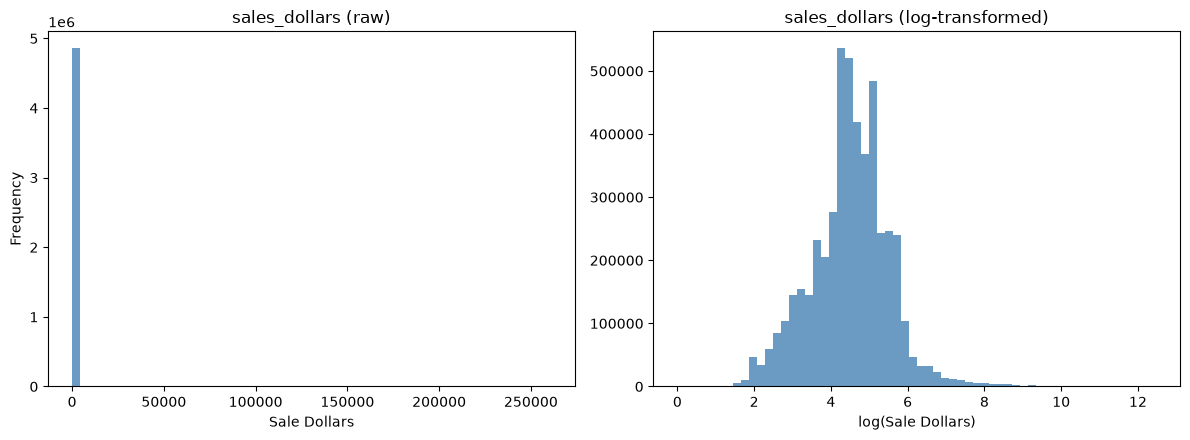

In [7]:
positive_sales = df_all.loc[df_all["sales_dollars"] > 0, "sales_dollars"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(positive_sales, bins=60, color="steelblue", alpha=0.8)
axes[0].set_title("sales_dollars (raw)")
axes[0].set_xlabel("Sale Dollars")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log(positive_sales), bins=60, color="steelblue", alpha=0.8)
axes[1].set_title("sales_dollars (log-transformed)")
axes[1].set_xlabel("log(Sale Dollars)")

plt.tight_layout()
plt.show()

## 3. Weather data by zip code (`otis_eda.ipynb`)

For each zip code that shows up in the liquor data, find the nearest Iowa
ASOS weather station (there are only 62 active stations for the state's 99
counties / 500+ zip codes, so exact-match isn't possible), pull daily
weather for that station, and build a zip-code-keyed weather table that can
be merged directly onto the sales data on `["store_zip_code", "ordered_on"]`.

Any sale whose zip code is missing, blank, or doesn't resolve to a station
(out-of-state zip, typo, etc.) falls back to that day's statewide average
across all stations in use, rather than being left blank — this is exactly
the set of "unknown county" rows flagged above.

(Note: the Census gazetteer is only published as a `.zip` — a plain `.txt`
request to it 404s — so we download the archive and read the `.txt` out of
it in memory, per the fix made directly in `otis_eda.ipynb`.)

In [8]:
def get_iowa_asos_stations():
    """Iowa ASOS station metadata (id, station's home county, lat/lon)."""
    url = "https://mesonet.agron.iastate.edu/geojson/network/IA_ASOS.geojson"
    data = requests.get(url, timeout=30).json()

    rows = []
    for feat in data["features"]:
        props = feat["properties"]
        lon, lat = feat["geometry"]["coordinates"]
        rows.append({
            "station": props["sid"],
            "station_name": props["sname"],
            "county": props["county"].upper(),
            "lat": lat,
            "lon": lon,
            "online": props["online"],
        })

    stations_df = pd.DataFrame(rows)
    return stations_df[stations_df["online"]].reset_index(drop=True)


def get_zip_centroids(zips_needed):
    """Centroid lat/lon for a set of 5-digit zip codes (Census ZCTA gazetteer)."""
    url = "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2024_Gazetteer/2024_Gaz_zcta_national.zip"
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        name = next(n for n in zf.namelist() if n.endswith(".txt"))
        with zf.open(name) as fh:
            zips_df = pd.read_csv(fh, sep="\t", dtype={"GEOID": str}, encoding="latin-1")

    zips_df.columns = [c.strip() for c in zips_df.columns]
    zips_df["zip"] = zips_df["GEOID"].str.zfill(5)
    zips_df = zips_df.rename(columns={"INTPTLAT": "lat", "INTPTLONG": "lon"})

    return zips_df.loc[zips_df["zip"].isin(zips_needed), ["zip", "lat", "lon"]].reset_index(drop=True)


def haversine_miles(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 3958.8 * 2 * np.arcsin(np.sqrt(a))


def clean_zip(series):
    return series.astype(str).str.strip().str.extract(r"(\d{5})")[0]


stations_df = get_iowa_asos_stations()

zips_needed = sorted(
    set(clean_zip(df_2025["store_zip_code"]).dropna())
    | set(clean_zip(df_2026["store_zip_code"]).dropna())
)

zip_centroids_df = get_zip_centroids(zips_needed)
unmatched_zips = sorted(set(zips_needed) - set(zip_centroids_df["zip"]))

zip_to_station = {}
for _, row in zip_centroids_df.iterrows():
    dists = haversine_miles(row["lat"], row["lon"], stations_df["lat"], stations_df["lon"])
    zip_to_station[row["zip"]] = stations_df.loc[dists.idxmin(), "station"]

zip_station_df = pd.DataFrame(zip_to_station.items(), columns=["store_zip_code", "station"])

print(f"{len(zip_to_station)} / {len(zips_needed)} zip codes matched to a station")
print(f"{len(unmatched_zips)} zip codes had no centroid on file "
      f"(will fall back to statewide avg): {unmatched_zips}")
print(f"{zip_station_df['station'].nunique()} unique stations used")
zip_station_df.head()

507 / 512 zip codes matched to a station
5 zip codes had no centroid on file (will fall back to statewide avg): ['52087', '52303', '52671', '52733', '57222']
61 unique stations used


,store_zip_code,station
0,50002,ADU
1,50003,PRO
2,50005,MIW
3,50006,IFA
4,50008,CNC


In [9]:
def fetch_iem_daily_weather(stations, start_date, end_date, network="IA_ASOS"):
    """Fetch daily weather summaries from the Iowa Environmental Mesonet."""
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    url = "https://mesonet.agron.iastate.edu/cgi-bin/request/daily.py"
    params = {
        "network": network,
        "stations": ",".join(sorted(set(stations))),
        "year1": start_date.year,
        "month1": start_date.month,
        "day1": start_date.day,
        "year2": end_date.year,
        "month2": end_date.month,
        "day2": end_date.day,
        "format": "csv",
    }

    resp = requests.get(url, params=params, timeout=120)
    resp.raise_for_status()

    weather_df = pd.read_csv(io.StringIO(resp.text))
    weather_df["day"] = pd.to_datetime(weather_df["day"])
    return weather_df


all_stations = zip_station_df["station"].unique()

station_weather_2025 = fetch_iem_daily_weather(
    all_stations, df_2025["ordered_on"].min(), df_2025["ordered_on"].max()
)
station_weather_2026 = fetch_iem_daily_weather(
    all_stations, df_2026["ordered_on"].min(), df_2026["ordered_on"].max()
)

weather_cols = [c for c in station_weather_2025.columns if c not in ("station", "day")]

# one row per zip code per day
weather_df_2025 = zip_station_df.merge(station_weather_2025, on="station", how="left")
weather_df_2026 = zip_station_df.merge(station_weather_2026, on="station", how="left")

# statewide daily average across every station in use -- the imputed fallback
statewide_avg_2025 = station_weather_2025.groupby("day")[weather_cols].mean().reset_index()
statewide_avg_2026 = station_weather_2026.groupby("day")[weather_cols].mean().reset_index()

print(weather_df_2025.shape, weather_df_2026.shape)
weather_df_2025.head()

(185055, 24) (123201, 24)


,store_zip_code,station,day,max_temp_f,min_temp_f,max_dewpoint_f,min_dewpoint_f,precip_in,avg_wind_speed_kts,avg_wind_drct,min_rh,avg_rh,max_rh,snow_in,snowd_in,min_feel,avg_feel,max_feel,max_wind_speed_kts,max_wind_gust_kts,srad_mj,climo_high_f,climo_low_f,climo_precip_in
0,50002,ADU,2025-01-01,33.8,19.4,26.6,17.6,0.00,4.006969,288.939850,74.077034,84.144035,100.00000,NaN,NaN,16.799290,22.657082,33.800000,10.0,16.0,NaN,28.7,10.5,0.03
1,50002,ADU,2025-01-02,26.6,10.4,24.8,8.6,0.00,3.832753,28.087036,85.399180,91.778206,100.00000,NaN,NaN,7.156008,17.615230,26.600000,9.0,NaN,NaN,28.5,10.3,0.03
2,50002,ADU,2025-01-03,21.2,8.6,19.4,6.8,0.06,4.017422,317.492580,67.049286,84.905200,92.62583,NaN,NaN,-1.549657,8.698599,17.600000,9.0,NaN,NaN,28.4,10.1,0.03
3,50002,ADU,2025-01-04,15.8,8.6,8.6,-0.4,0.00,6.665505,34.344624,60.985985,71.897064,78.51280,NaN,NaN,-5.489315,-0.105899,8.600000,12.0,16.0,NaN,28.3,9.9,0.03
4,50002,ADU,2025-01-05,15.8,10.4,6.8,-2.2,0.00,12.414634,2.522594,47.772910,62.318665,78.51280,NaN,NaN,-7.735320,-3.445042,3.370198,18.0,23.0,NaN,28.1,9.8,0.03


### Join weather onto the liquor sales data

`attach_weather` merges on `store_zip_code` + date, then fills any row that
didn't get a match with that day's statewide average.

In [10]:
def attach_weather(df, weather_df, statewide_avg, weather_cols):
    """Left-join weather onto liquor sales by (store_zip_code, ordered_on),
    then fill any unmatched row (missing/blank/out-of-state zip -- which in
    this data is exactly the unknown-county rows too) with that day's
    statewide average."""
    df = df.copy()
    df["store_zip_code"] = clean_zip(df["store_zip_code"])

    weather_keyed = weather_df.drop(columns="station").rename(columns={"day": "ordered_on"})
    merged = df.merge(weather_keyed, on=["store_zip_code", "ordered_on"], how="left")

    statewide_keyed = statewide_avg.rename(columns={"day": "ordered_on"})
    statewide_keyed = statewide_keyed.rename(columns={c: f"{c}_statewide" for c in weather_cols})
    merged = merged.merge(statewide_keyed, on="ordered_on", how="left")

    for col in weather_cols:
        merged[col] = merged[col].fillna(merged[f"{col}_statewide"])

    return merged.drop(columns=[f"{c}_statewide" for c in weather_cols])


df_2025_weather = attach_weather(df_2025, weather_df_2025, statewide_avg_2025, weather_cols)
df_2026_weather = attach_weather(df_2026, weather_df_2026, statewide_avg_2026, weather_cols)
df_all_weather = pd.concat([df_2025_weather, df_2026_weather], ignore_index=True)

print(df_2025_weather.shape, df_2026_weather.shape, df_all_weather.shape)
print("rows still missing weather after fallback:", df_all_weather[weather_cols[0]].isna().sum())
df_all_weather.head()

(2907817, 45) (1968354, 45) (4876171, 45)
rows still missing weather after fallback: 0


,invoice_id,ordered_on,store_no,store_name,store_address,store_city,store_zip_code,county_fips_code,county_name,category_code,category_name,vendor_number,vendor_name,item_no,im_desc,pack,bottle_volume_ml,sales_bottles,sales_dollars,sales_liters,sales_gallons,state_bottle_cost,state_bottle_retail,year,max_temp_f,min_temp_f,max_dewpoint_f,min_dewpoint_f,precip_in,avg_wind_speed_kts,avg_wind_drct,min_rh,avg_rh,max_rh,snow_in,snowd_in,min_feel,avg_feel,max_feel,max_wind_speed_kts,max_wind_gust_kts,srad_mj,climo_high_f,climo_low_f,climo_precip_in
0,INV-78192100069,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1022200,100% AGAVE TEQUILA,395,PROXIMO,87510,1800 SILVER,12,750,3,74.25,2.25,0.59,NaN,NaN,2025,30.2,21.2,24.8,15.8,0.001845,9.303136,293.75946,68.17778,81.72814,100.0,0.000033,0.00002,8.635962,17.926886,24.8,23.0,30.0,NaN,29.2,11.2,0.04
1,INV-78192100072,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1022200,100% AGAVE TEQUILA,065,JIM BEAM BRANDS,88540,HORNITOS LIME SHOT,12,750,12,270.00,9.00,2.37,NaN,NaN,2025,30.2,21.2,24.8,15.8,0.001845,9.303136,293.75946,68.17778,81.72814,100.0,0.000033,0.00002,8.635962,17.926886,24.8,23.0,30.0,NaN,29.2,11.2,0.04
2,INV-78192100070,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1022200,100% AGAVE TEQUILA,421,SAZERAC COMPANY INC,88036,MARGARITAVILLE SILVER TEQUILA,12,750,3,41.85,2.25,0.59,NaN,NaN,2025,30.2,21.2,24.8,15.8,0.001845,9.303136,293.75946,68.17778,81.72814,100.0,0.000033,0.00002,8.635962,17.926886,24.8,23.0,30.0,NaN,29.2,11.2,0.04
3,INV-78192100071,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1022200,100% AGAVE TEQUILA,460,SHAW-ROSS INTERNATIONAL,88172,SANTO TEQUILA REPOSADO,6,750,2,82.50,1.50,0.39,NaN,NaN,2025,30.2,21.2,24.8,15.8,0.001845,9.303136,293.75946,68.17778,81.72814,100.0,0.000033,0.00002,8.635962,17.926886,24.8,23.0,30.0,NaN,29.2,11.2,0.04
4,INV-78192100061,2025-01-01,2505,HY-VEE WINE AND SPIRITS (1038) / BOONE,1111 8TH ST,BOONE,50036,19015,BOONE,1081300,AMERICAN CORDIALS & LIQUEURS,065,JIM BEAM BRANDS,85526,DEKUYPER BLUE CURACAO,12,750,12,94.56,9.00,2.37,NaN,NaN,2025,30.2,21.2,24.8,15.8,0.001845,9.303136,293.75946,68.17778,81.72814,100.0,0.000033,0.00002,8.635962,17.926886,24.8,23.0,30.0,NaN,29.2,11.2,0.04


## 4. University-city flag (`jake_eda.ipynb`)

`jake_eda.ipynb` flagged whether a sale's `store_city` hosts an Iowa
college or university (sourced from [Wikipedia's list of colleges and
universities in Iowa](https://en.wikipedia.org/wiki/List_of_colleges_and_universities_in_Iowa)).
That source CSV wasn't checked into the repo, so the resulting city list is
reproduced here directly from that notebook's own output rather than
re-scraped.

In [11]:
# Cities with an Iowa college/university, from jake_eda.ipynb
# (source: https://en.wikipedia.org/wiki/List_of_colleges_and_universities_in_Iowa)
university_cities = [
    "iowa city", "ames", "cedar falls", "ankeny", "davenport",
    "iowa falls", "waterloo", "ottumwa", "fort dodge", "estherville",
    "council bluffs", "cedar rapids", "marshalltown", "mason city",
    "calmar", "sheldon", "west burlington", "creston", "sioux city",
    "storm lake", "pella", "dubuque", "mount vernon", "des moines",
    "epworth", "sioux center", "lamoni", "grinnell", "decorah",
    "fairfield", "orange city", "indianola", "fayette", "waverly",
    "oskaloosa", "forest city",
]

df_all_weather["is_university_city"] = (
    df_all_weather["store_city"].str.lower().isin(university_cities)
)

df_all_weather["is_university_city"].value_counts(dropna=False)

is_university_city
True     2461472
False    2414699
Name: count, dtype: int64

## 5. Sales aggregations (`eda.ipynb`, extended to both years)

Re-running `eda.ipynb`'s aggregations (which only covered 2026) across both
years via DuckDB, with `year` broken out so 2025 vs. 2026 can be compared
directly.

In [12]:
combined_sql = """
    SELECT *, 2025 AS year FROM 'liquor_2025.parquet'
    UNION ALL BY NAME
    SELECT *, 2026 AS year FROM 'liquor_2026.parquet'
"""

zip_sales = con.execute(f"""
    SELECT
        year,
        store_zip_code,
        SUM(TRY_CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales,
        COUNT(DISTINCT store_no) AS num_stores
    FROM ({combined_sql})
    WHERE store_zip_code IS NOT NULL
    GROUP BY year, store_zip_code
    ORDER BY year, total_bottles DESC
""").df()

zip_sales.groupby("year").head(5)

,year,store_zip_code,total_bottles,total_sales,num_stores
0,2025,50314,1025655.0,18723278.49,6
1,2025,51501,1002481.0,12992543.53,32
2,2025,50320,994552.0,16863384.37,8
3,2025,52240,839166.0,11975292.99,31
4,2025,50266,835313.0,16607491.36,28
509,2026,50320,739864.0,12655980.41,8
510,2026,51501,671392.0,8735293.63,31
511,2026,50314,643693.0,11271890.35,6
512,2026,52240,585900.0,8132977.25,31
513,2026,52402,531410.0,7025030.50,32


In [13]:
store_sales = con.execute(f"""
    SELECT
        year,
        store_no,
        store_name,
        store_city,
        store_zip_code,
        SUM(TRY_CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales
    FROM ({combined_sql})
    GROUP BY year, store_no, store_name, store_city, store_zip_code
    ORDER BY year, total_bottles DESC
""").df()

store_sales.groupby("year").head(5)

,year,store_no,store_name,store_city,store_zip_code,total_bottles,total_sales
0,2025,2633,HY-VEE #3 / BDI / DES MOINES,DES MOINES,50320,805480.0,15508357.03
1,2025,4829,CENTRAL CITY 2,DES MOINES,50314,775807.0,15292898.07
2,2025,2512,HY-VEE WINE AND SPIRITS #1 (1281) / IOWA CITY,IOWA CITY,52240,416374.0,6434571.10
3,2025,5916,ANOTHER ROUND / DEWITT,DEWITT,52742,362948.0,7176293.30
4,2025,3773,BENZ DISTRIBUTING,CEDAR RAPIDS,52401,317674.0,6054744.10
2346,2026,2633,HY-VEE #3 / BDI / DES MOINES,DES MOINES,50320,582879.0,11198427.01
2347,2026,4829,CENTRAL CITY 2,DES MOINES,50314,463878.0,9092240.04
2348,2026,2512,HY-VEE WINE AND SPIRITS #1 (1281) / IOWA CITY,IOWA CITY,52240,292474.0,4377713.44
2349,2026,5916,ANOTHER ROUND / DEWITT,DEWITT,52742,257302.0,4999241.81
2350,2026,3773,BENZ DISTRIBUTING,CEDAR RAPIDS,52401,207527.0,4015879.03


In [14]:
monthly_sales = con.execute(f"""
    SELECT
        year,
        MONTH(ordered_on) AS month,
        SUM(TRY_CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales
    FROM ({combined_sql})
    GROUP BY year, month
    ORDER BY year, month
""").df()

print(f"2025 months present: {sorted(monthly_sales.loc[monthly_sales.year == 2025, 'month'])}")
print(f"2026 months present: {sorted(monthly_sales.loc[monthly_sales.year == 2026, 'month'])}")
print("--> 2026 is year-to-date; only compare months both years actually have.")
monthly_sales

2025 months present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2026 months present: [1, 2, 3, 4, 5, 6, 7, 8]
--> 2026 is year-to-date; only compare months both years actually have.


,year,month,total_bottles,total_sales
0,2025,1,2309799.0,3.111168e+07
1,2025,2,2206814.0,3.130870e+07
2,2025,3,2416496.0,3.351880e+07
3,2025,4,2595432.0,3.549999e+07
4,2025,5,2571012.0,3.558968e+07
5,2025,6,2642511.0,3.594628e+07
6,2025,7,2542822.0,3.609424e+07
7,2025,8,2550030.0,3.421323e+07
8,2025,9,2550970.0,3.515777e+07
9,2025,10,2779007.0,4.004714e+07


In [15]:
category_sales = con.execute(f"""
    SELECT
        category_code,
        category_name,
        SUM(TRY_CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales,
        AVG(state_bottle_retail) AS avg_retail_price
    FROM ({combined_sql})
    WHERE category_name IS NOT NULL
    GROUP BY category_code, category_name
    ORDER BY total_bottles DESC
""").df()

category_sales.head(10)

,category_code,category_name,total_bottles,total_sales,avg_retail_price
0,1031100,AMERICAN VODKAS,12654986.0,1.275611e+08,10.455519
1,1081600,WHISKEY LIQUEUR,9199647.0,5.249679e+07,16.491821
2,1012100,CANADIAN WHISKIES,5348672.0,8.771205e+07,17.583319
3,1011200,STRAIGHT BOURBON WHISKIES,3364759.0,7.817526e+07,26.754324
4,1062400,SPICED RUM,2509953.0,3.992486e+07,14.180736
5,1081400,AMERICAN SCHNAPPS,2362147.0,1.689852e+07,38.292769
6,1022200,100% AGAVE TEQUILA,2325953.0,6.464807e+07,32.654932
7,1031200,AMERICAN FLAVORED VODKA,1828373.0,2.083330e+07,13.650645
8,1022100,MIXTO TEQUILA,1463616.0,2.011119e+07,16.570107
9,1032100,IMPORTED VODKAS,1457989.0,2.329416e+07,17.736299


In [16]:
season_sales = con.execute(f"""
    SELECT
        year,
        CASE
            WHEN MONTH(ordered_on) IN (12, 1, 2) THEN 'Winter'
            WHEN MONTH(ordered_on) IN (3, 4, 5) THEN 'Spring'
            WHEN MONTH(ordered_on) IN (6, 7, 8) THEN 'Summer'
            ELSE 'Fall'
        END AS season,
        SUM(TRY_CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales
    FROM ({combined_sql})
    GROUP BY year, season
    ORDER BY year, total_bottles DESC
""").df()

season_sales

,year,season,total_bottles,total_sales
0,2025,Winter,10215225.0,1.457446e+08
1,2025,Fall,9842360.0,1.394275e+08
2,2025,Summer,7735363.0,1.062537e+08
3,2025,Spring,7582940.0,1.046085e+08
4,2026,Summer,12010012.0,1.637320e+08
5,2026,Spring,7475080.0,1.023207e+08
6,2026,Winter,4355193.0,5.870150e+07


In [17]:
county_sales = con.execute(f"""
    SELECT
        year,
        county_fips_code,
        county_name,
        SUM(TRY_CAST(sales_bottles AS INTEGER)) AS total_bottles,
        SUM(sales_dollars) AS total_sales,
        COUNT(DISTINCT store_no) AS num_stores,
        SUM(TRY_CAST(sales_bottles AS INTEGER)) / COUNT(DISTINCT store_no) AS bottles_per_store
    FROM ({combined_sql})
    WHERE county_fips_code IS NOT NULL
    GROUP BY year, county_fips_code, county_name
    ORDER BY year, total_bottles DESC
""").df()

county_sales.groupby("year").head(5)

,year,county_fips_code,county_name,total_bottles,total_sales,num_stores,bottles_per_store
0,2025,19153,POLK,7904351.0,1.135650e+08,310,25497.906452
1,2025,19113,LINN,3130004.0,4.250084e+07,146,21438.383562
2,2025,19163,SCOTT,2441449.0,3.135762e+07,98,24912.744898
3,2025,19013,BLACK HAWK,1818475.0,2.316699e+07,92,19766.032609
4,2025,19103,JOHNSON,1811059.0,2.802325e+07,89,20348.977528
99,2026,19153,POLK,5367468.0,7.564214e+07,311,17258.739550
100,2026,19113,LINN,2118054.0,2.839419e+07,144,14708.708333
101,2026,19163,SCOTT,1642736.0,2.037231e+07,100,16427.360000
102,2026,19103,JOHNSON,1271779.0,1.898841e+07,96,13247.697917
103,2026,19013,BLACK HAWK,1189777.0,1.488074e+07,84,14164.011905


## 6. Visualizations (`eda.ipynb`, extended to both years where useful)

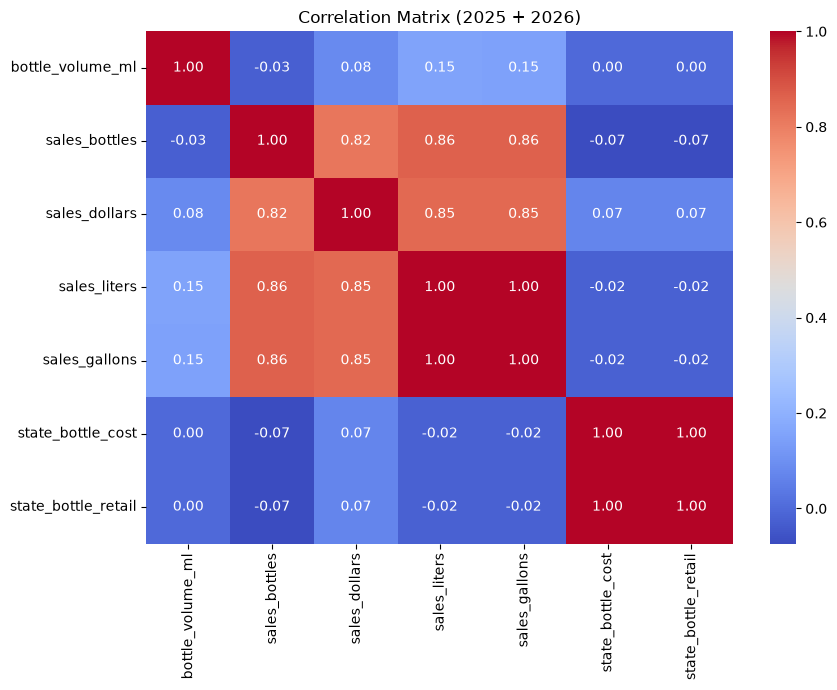

In [18]:
numeric_cols_for_corr = [
    "bottle_volume_ml", "sales_bottles", "sales_dollars",
    "sales_liters", "sales_gallons", "state_bottle_cost", "state_bottle_retail",
]
corr = df_all[numeric_cols_for_corr].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (2025 + 2026)")
plt.tight_layout()
plt.show()

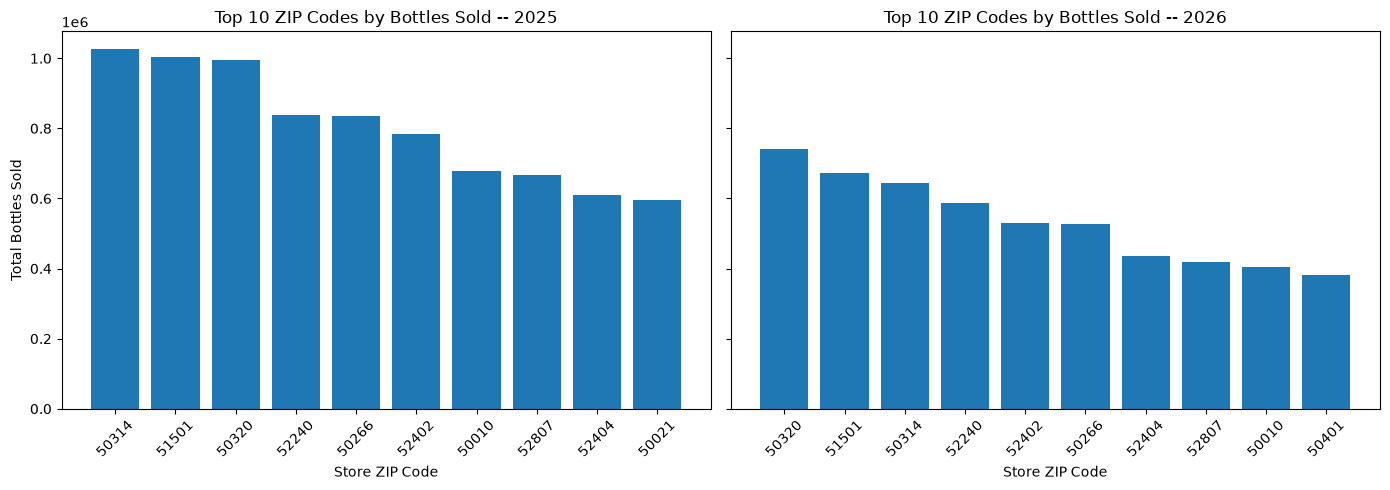

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, year in zip(axes, [2025, 2026]):
    top_zips = zip_sales[zip_sales.year == year].head(10)
    ax.bar(top_zips["store_zip_code"].astype(str), top_zips["total_bottles"])
    ax.set_title(f"Top 10 ZIP Codes by Bottles Sold -- {year}")
    ax.set_xlabel("Store ZIP Code")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Total Bottles Sold")
plt.tight_layout()
plt.show()

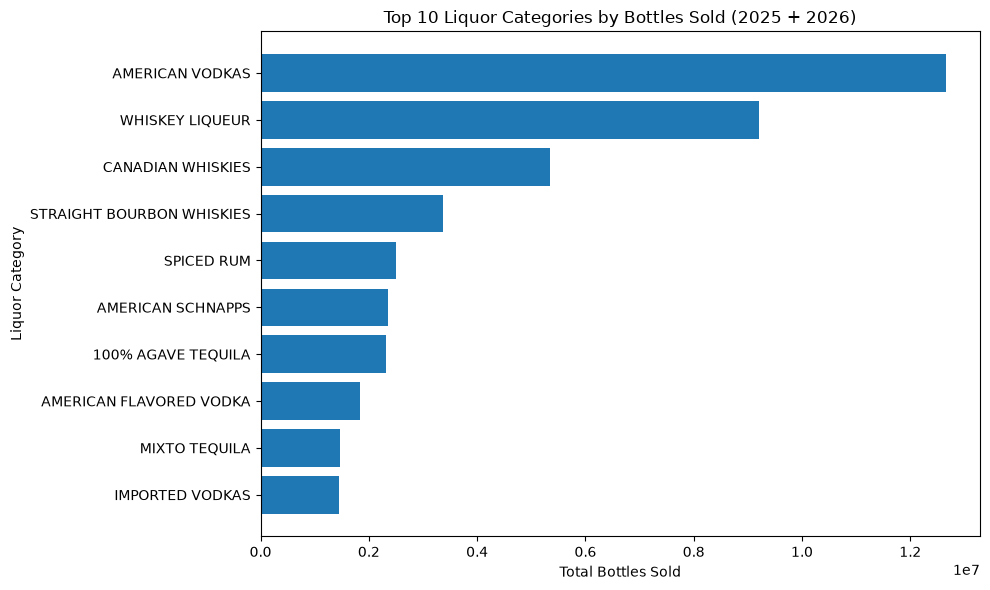

In [20]:
top_categories_bottles = category_sales.sort_values("total_bottles", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_categories_bottles["category_name"], top_categories_bottles["total_bottles"])
plt.xlabel("Total Bottles Sold")
plt.ylabel("Liquor Category")
plt.title("Top 10 Liquor Categories by Bottles Sold (2025 + 2026)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

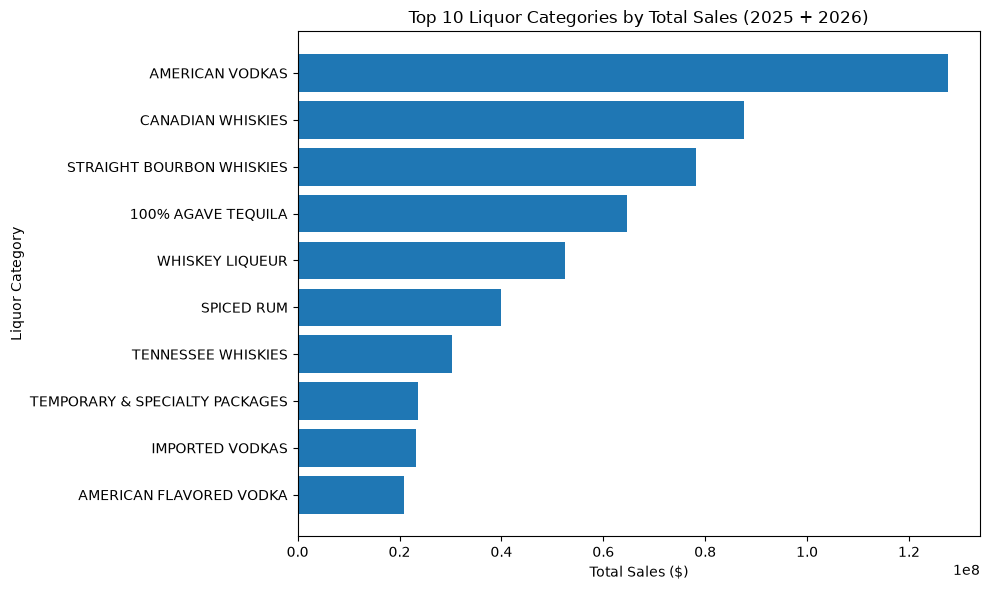

In [21]:
top_categories_dollars = category_sales.sort_values("total_sales", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_categories_dollars["category_name"], top_categories_dollars["total_sales"])
plt.xlabel("Total Sales ($)")
plt.ylabel("Liquor Category")
plt.title("Top 10 Liquor Categories by Total Sales (2025 + 2026)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

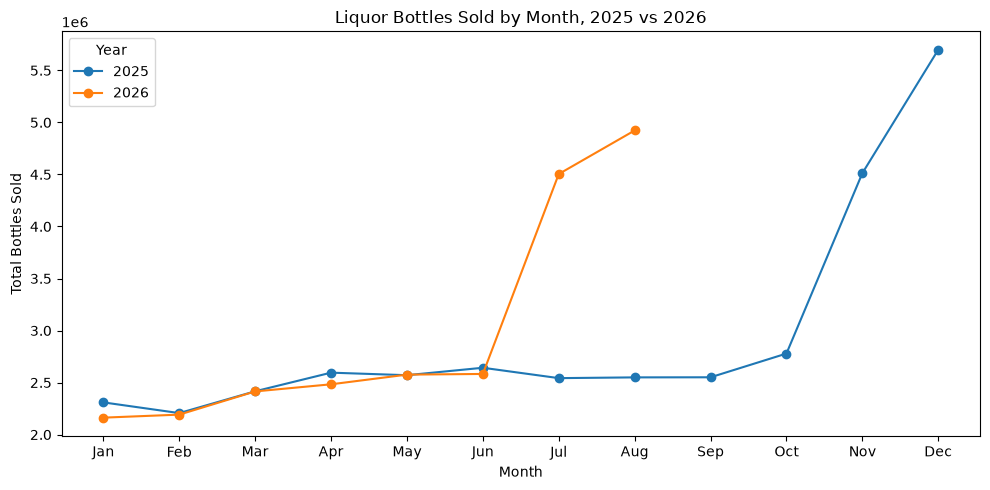

In [22]:
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))
for year, group in monthly_sales.groupby("year"):
    plt.plot(group["month"], group["total_bottles"], marker="o", label=str(year))

plt.xlabel("Month")
plt.ylabel("Total Bottles Sold")
plt.title("Liquor Bottles Sold by Month, 2025 vs 2026")
plt.xticks(range(1, 13), month_names)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

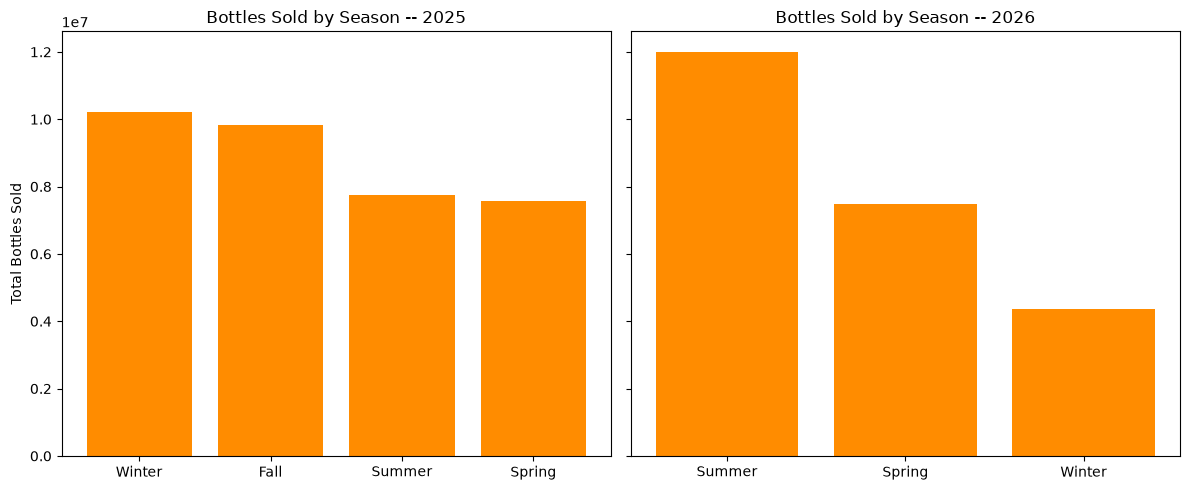

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, year in zip(axes, [2025, 2026]):
    s = season_sales[season_sales.year == year].sort_values("total_bottles", ascending=False)
    ax.bar(s["season"], s["total_bottles"], color="darkorange")
    ax.set_title(f"Bottles Sold by Season -- {year}")

axes[0].set_ylabel("Total Bottles Sold")
plt.tight_layout()
plt.show()

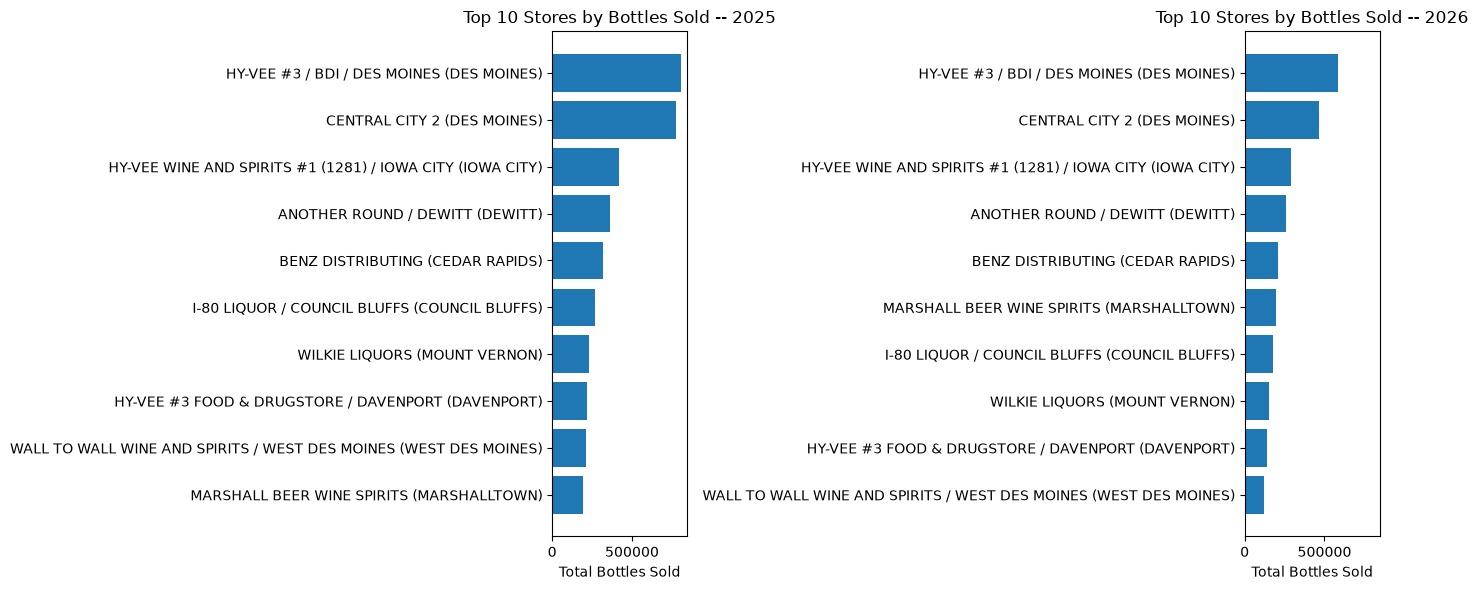

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for ax, year in zip(axes, [2025, 2026]):
    top_stores = store_sales[store_sales.year == year].head(10).copy()
    top_stores["store_label"] = top_stores["store_name"] + " (" + top_stores["store_city"] + ")"
    ax.barh(top_stores["store_label"], top_stores["total_bottles"])
    ax.set_title(f"Top 10 Stores by Bottles Sold -- {year}")
    ax.invert_yaxis()

axes[0].set_xlabel("Total Bottles Sold")
axes[1].set_xlabel("Total Bottles Sold")
plt.tight_layout()
plt.show()

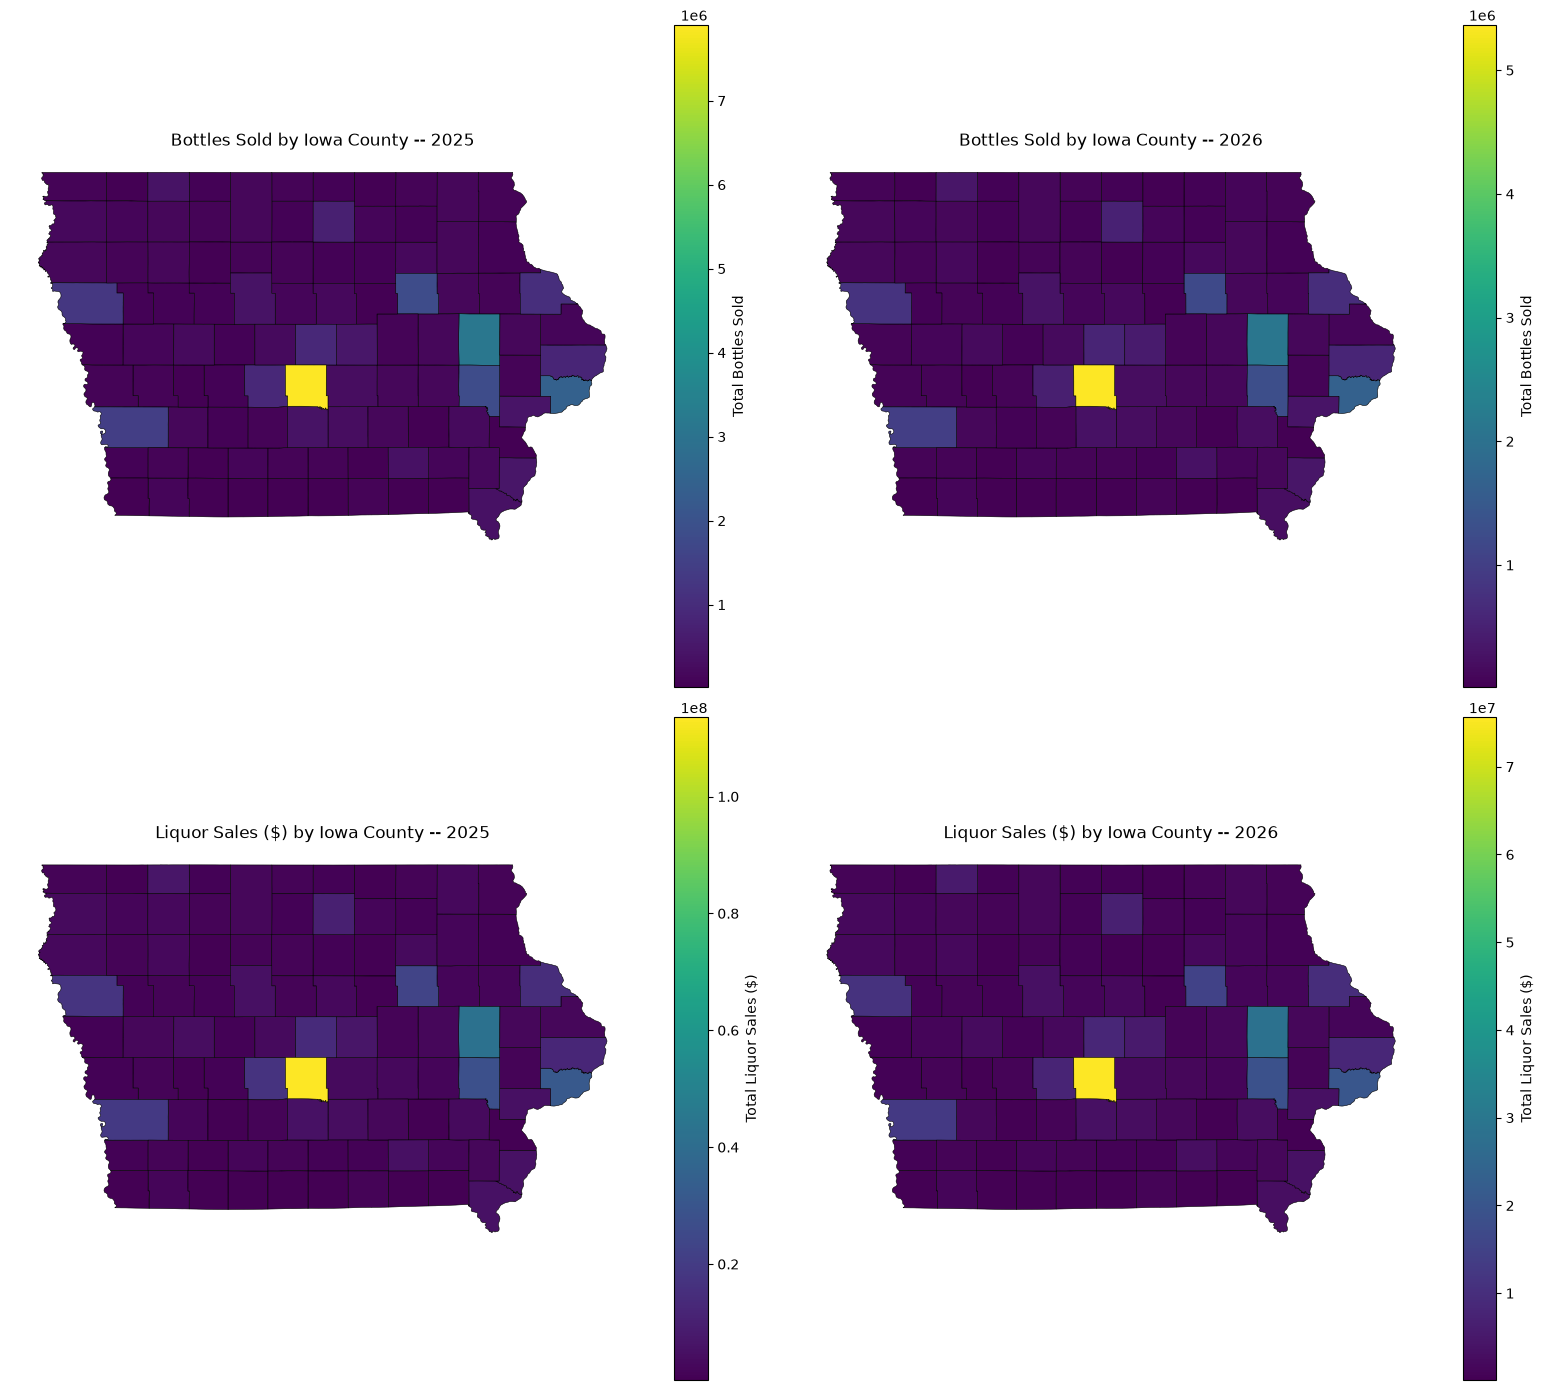

In [26]:
import geopandas as gpd

counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_county_500k.zip")
iowa = counties[counties["STATEFP"] == "19"].copy()
iowa["GEOID"] = iowa["GEOID"].astype(str)

county_sales_fmt = county_sales.copy()
county_sales_fmt["county_fips_code"] = county_sales_fmt["county_fips_code"].astype(str).str.zfill(5)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for col_idx, year in enumerate([2025, 2026]):
    iowa_sales = iowa.merge(
        county_sales_fmt[county_sales_fmt.year == year],
        left_on="GEOID", right_on="county_fips_code", how="left",
    )

    iowa_sales.plot(column="total_bottles", ax=axes[0, col_idx], legend=True,
                     edgecolor="black", linewidth=0.4,
                     legend_kwds={"label": "Total Bottles Sold"})
    axes[0, col_idx].set_title(f"Bottles Sold by Iowa County -- {year}")
    axes[0, col_idx].axis("off")

    iowa_sales.plot(column="total_sales", ax=axes[1, col_idx], legend=True,
                     edgecolor="black", linewidth=0.4,
                     legend_kwds={"label": "Total Liquor Sales ($)"})
    axes[1, col_idx].set_title(f"Liquor Sales ($) by Iowa County -- {year}")
    axes[1, col_idx].axis("off")

plt.tight_layout()
plt.show()

## 7. University-city vs. non-university-city sales (`jake_eda.ipynb`)

Recomputed directly from `df_all_weather` (2025 + 2026 combined) rather
than reusing `jake_eda.ipynb`'s printed numbers, since that notebook's
*total*-gallons ratio and *average*-gallons ratio didn't agree with each
other in a way that's consistent with the underlying row counts. Redoing it
here on the current data:

In [27]:
uni = df_all_weather[df_all_weather["is_university_city"]]
non_uni = df_all_weather[~df_all_weather["is_university_city"]]

sum_ratio = uni["sales_gallons"].sum() / non_uni["sales_gallons"].sum()
avg_ratio = uni["sales_gallons"].mean() / non_uni["sales_gallons"].mean()

print(f"University-city rows:     {len(uni):,}")
print(f"Non-university-city rows: {len(non_uni):,}")
print(f"Total gallons sold, university cities:     {uni['sales_gallons'].sum():,.0f}")
print(f"Total gallons sold, non-university cities:  {non_uni['sales_gallons'].sum():,.0f}")
print(f"Ratio of totals (university / non):   {sum_ratio:.3f}")
print(f"Ratio of per-transaction averages:    {avg_ratio:.3f}")
print()
print("Both ratios land in the same ~1.25x range here -- university cities sell")
print("about 25% more alcohol by volume, both in total and per transaction.")
print("(jake_eda.ipynb's original avg-ratio of ~2.49x doesn't reconcile with its")
print("own ~1.25x total-ratio given its row counts, so that figure looks like a")
print("bug or a stale intermediate variable rather than a real effect -- use")
print("the numbers above instead.)")

University-city rows:     2,461,472
Non-university-city rows: 2,414,699
Total gallons sold, university cities:     6,080,907
Total gallons sold, non-university cities:  4,824,370
Ratio of totals (university / non):   1.260
Ratio of per-transaction averages:    1.237

Both ratios land in the same ~1.25x range here -- university cities sell
about 25% more alcohol by volume, both in total and per transaction.
(jake_eda.ipynb's original avg-ratio of ~2.49x doesn't reconcile with its
own ~1.25x total-ratio given its row counts, so that figure looks like a
bug or a stale intermediate variable rather than a real effect -- use
the numbers above instead.)


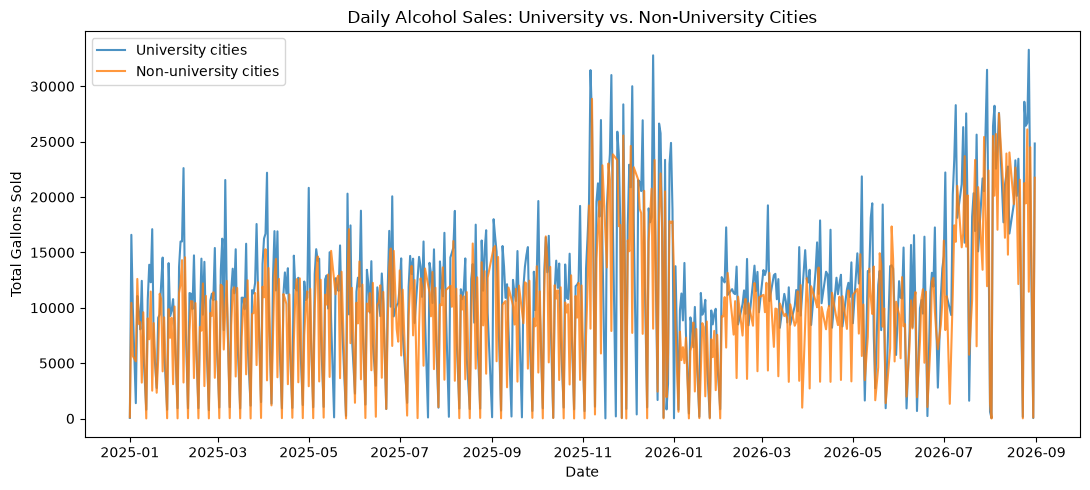

In [28]:
daily_uni = uni.groupby("ordered_on")["sales_gallons"].sum()
daily_non_uni = non_uni.groupby("ordered_on")["sales_gallons"].sum()

plt.figure(figsize=(11, 5))
plt.plot(daily_uni.index, daily_uni.values, label="University cities", alpha=0.8)
plt.plot(daily_non_uni.index, daily_non_uni.values, label="Non-university cities", alpha=0.8)
plt.xlabel("Date")
plt.ylabel("Total Gallons Sold")
plt.title("Daily Alcohol Sales: University vs. Non-University Cities")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Does weather relate to sales?

None of the individual notebooks actually checked this, even though
`otis_eda.ipynb` did all the work to pull the weather data in — this is the
one genuinely new piece of analysis in this notebook. Aggregate to
statewide daily totals/averages and look for a relationship between
temperature/precipitation and how much alcohol Iowa buys that day.

In [29]:
daily = df_all_weather.groupby("ordered_on").agg(
    total_sales_dollars=("sales_dollars", "sum"),
    total_bottles=("sales_bottles", "sum"),
    avg_max_temp_f=("max_temp_f", "mean"),
    total_precip_in=("precip_in", "mean"),  # already a per-zip average; mean-of-means is the statewide figure
).reset_index()

corr_cols = ["total_sales_dollars", "total_bottles", "avg_max_temp_f", "total_precip_in"]
daily[corr_cols].corr()

,total_sales_dollars,total_bottles,avg_max_temp_f,total_precip_in
total_sales_dollars,1.000000,0.988311,0.014265,-0.008835
total_bottles,0.988311,1.000000,0.030474,-0.000335
avg_max_temp_f,0.014265,0.030474,1.000000,0.205227
total_precip_in,-0.008835,-0.000335,0.205227,1.000000


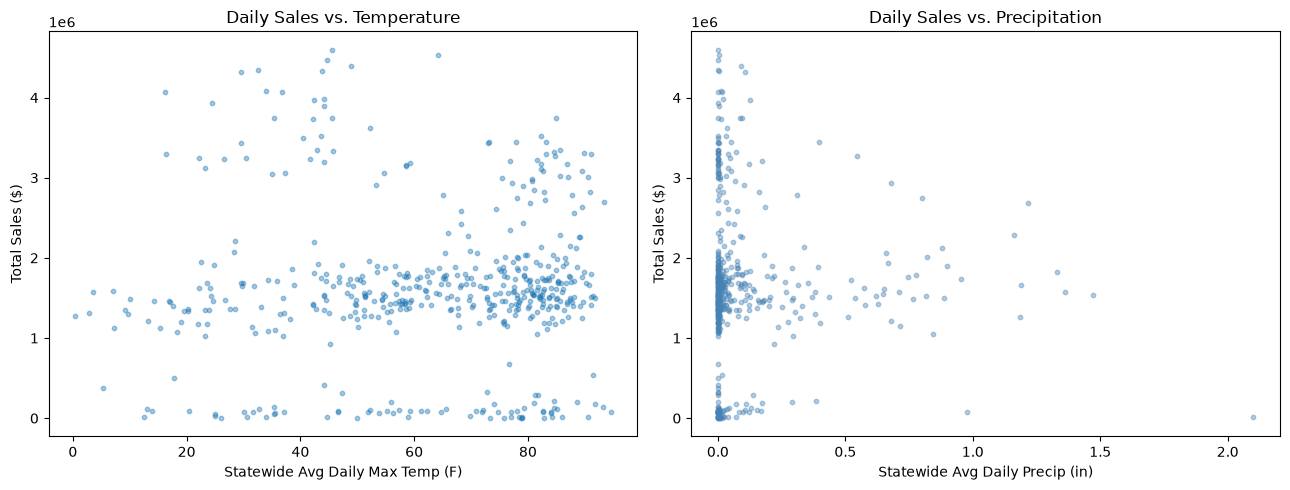

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(daily["avg_max_temp_f"], daily["total_sales_dollars"], alpha=0.4, s=10)
axes[0].set_xlabel("Statewide Avg Daily Max Temp (F)")
axes[0].set_ylabel("Total Sales ($)")
axes[0].set_title("Daily Sales vs. Temperature")

axes[1].scatter(daily["total_precip_in"], daily["total_sales_dollars"], alpha=0.4, s=10, color="steelblue")
axes[1].set_xlabel("Statewide Avg Daily Precip (in)")
axes[1].set_ylabel("Total Sales ($)")
axes[1].set_title("Daily Sales vs. Precipitation")

plt.tight_layout()
plt.show()

Keep in mind the big driver of the monthly/seasonal pattern above is
the **Nov/Dec holiday spike** in 2025, which is also the coldest part of
the year — so a naive temperature-vs-sales correlation is going to pick up
"holidays are cold" as much as any real weather effect. A cleaner read
excludes Nov/Dec (or looks within a single season) before drawing
conclusions about weather driving demand day-to-day.

In [31]:
daily_no_holidays = daily[~daily["ordered_on"].dt.month.isin([11, 12])]
daily_no_holidays[corr_cols].corr()

,total_sales_dollars,total_bottles,avg_max_temp_f,total_precip_in
total_sales_dollars,1.000000,0.984635,0.216159,0.052294
total_bottles,0.984635,1.000000,0.216986,0.056733
avg_max_temp_f,0.216159,0.216986,1.000000,0.182639
total_precip_in,0.052294,0.056733,0.182639,1.000000


## Summary of key findings

- **Data pipeline**: JSON -> DuckDB -> parquet -> pandas loads cleanly for
  both years (`eda.ipynb`, `otis_eda.ipynb`); `sales_bottles` needs an
  explicit numeric cast (`minh.ipynb`).
- **Data quality**: 2025 has 486 rows missing location entirely
  (county/zip/city all null together); 2026 has ~4,100 rows missing just
  the county FIPS code. A small number of rows each year (~0.05-0.1%) have
  negative `sales_dollars`, consistent with returns/credits rather than bad
  data (`minh.ipynb`).
- **Coverage caveat**: 2025 is a complete year; 2026 is year-to-date
  (through August as of this notebook) -- any month/season comparison
  between the two years should stick to the months both years actually have.
- **Where sales happen**: heavily concentrated in Polk, Linn, and Scott
  counties and their major-city zip codes; a handful of Hy-Vee/large
  retailer locations dominate the top-stores list (`eda.ipynb`).
- **What sells**: American vodkas, whiskey liqueur, and Canadian whiskies
  are the top categories by volume. Seasonally, the complete 2025 data
  shows demand actually peaking in Fall/Winter, driven by a large Nov-Dec
  holiday spike; year-to-date 2026 (through August) naturally shows Summer
  as its top season so far, since it hasn't reached the holidays yet
  (`eda.ipynb`).
- **University cities**: sell about **25% more alcohol** by volume than
  non-university cities, both in total and per transaction -- a materially
  smaller effect than `jake_eda.ipynb` originally reported for the average
  ratio, which didn't reconcile with its own total-ratio number
  (`jake_eda.ipynb`, recomputed here).
- **Weather**: the zip-level weather join (`otis_eda.ipynb`) resolves the
  large majority of sales to a real nearby station, with a statewide-average
  fallback for the rest. A same-day correlation between temperature/
  precipitation and statewide sales is weak and confounded by the Nov/Dec
  holiday spike being both cold and high-volume -- worth revisiting with
  lagged weather or within-season comparisons rather than a flat same-day
  correlation.